In [1]:
import numpy as np
import pyshtools as pysh
import boule as bl
import pandas as pd
import xarray as xr
import harmonica as hm
import verde as vd
from pathlib import Path
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

pygmt-session [ERROR]: Cannot find the PSL_UTF-8 encoding
begin [ERROR]: Cannot find the PSL_UTF-8 encoding
d:\conda_envs\planet\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
height = 11e3
porosity = 0.12

In [3]:
# 通用画图代码
def simple_map_plot(da, title="", cbar_label="", cmap="jet", filename=None):
    """
    da: xarray.DataArray dims ('lat','lon'), coords 'lat','lon'
    兼容 lon 为 0-360 或 -180-180；自动 wrap 到 [-180,180) 并排序
    """
    lon = da["lon"].values.astype(float)
    lat = da["lat"].values.astype(float)
    data = da.values

    # --- 关键修正：把 0~360 经度转换到 -180~180，并按经度排序 ---
    if np.nanmax(lon) > 180:
        lon_wrapped = ((lon + 180) % 360) - 180  # -> [-180,180)
        idx = np.argsort(lon_wrapped)
        lon_plot = lon_wrapped[idx]
        data_plot = data[:, idx]
    else:
        lon_plot = lon
        data_plot = data

    fig = plt.figure(figsize=(10, 4.8), dpi=150)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, linestyle="--", alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    mesh = ax.pcolormesh(
        lon_plot, lat, data_plot,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap
    )

    ax.set_title(title)
    cbar = plt.colorbar(mesh, ax=ax, orientation="vertical", shrink=0.85, pad=0.03)
    if cbar_label:
        cbar.set_label(cbar_label)

    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename, bbox_inches="tight")
    plt.show()
    return fig, ax

In [4]:
test=True
PROJECT_ROOT = Path.cwd().parent
data_filename=PROJECT_ROOT/"data/density_no_mare_n3000_f3050_719.sh"
if test:
    result_filename=PROJECT_ROOT/"data/boueguer_tesseroid_11km_1deg.csv"
else:
    result_filename=PROJECT_ROOT/"data/boueguer_tesseroid_11km.csv"

In [5]:
# 密度
densityfile = data_filename
density = pysh.SHCoeffs.from_file(densityfile, lmax=719)
density_grid=density.expand(grid='DH',lmax=719,extend=False)
density_xr=density_grid.to_xarray()
# 重力
pot=pysh.datasets.Moon.GRGM1200B()
pot.set_omega(bl.Moon2015.angular_velocity)
pot=pot.change_ref(gm=bl.Moon2015.geocentric_grav_const, r0=bl.Moon2015.radius)
pot_grid= pot.expand(lmax=539, a=bl.Moon2015.radius + height, f=0, normal_gravity=False, extend=False)
pot_xr=pot_grid.to_xarray()
# 地形
topo=pysh.datasets.Moon.LDEM_shape_pa()
topo_grid=topo.expand(grid='DH',lmax=1200,extend=False)
topo_xr=topo_grid.to_xarray()

In [6]:
shape = tuple(s + 1 for s in pot_xr.radial.shape)

In [7]:
if test:
    region=(0, 359.99999, -90, 90)
    grid_longitude, grid_latitude = vd.grid_coordinates(region=region, shape=(181,361))
else:
    region=(0, 359.99999, -90, 90)
    grid_longitude, grid_latitude = vd.grid_coordinates(region=region, shape=(181,361))
lon_o=np.sort(np.unique(grid_longitude))
lat_o=np.sort(np.unique(grid_latitude))
lon = 0.5 * (lon_o[:-1] + lon_o[1:])
lat = 0.5 * (lat_o[:-1] + lat_o[1:])
pot_xr_sub=pot_xr.interp(lat=lat,lon=lon)
density_xr_sub=density_xr.interp(lat=lat,lon=lon)
topo_xr_sub=topo_xr.interp(lat=lat,lon=lon)
LON, LAT = np.meshgrid(lon, lat) 

In [8]:
Moon2015_el=bl.Moon2015
gamma=Moon2015_el.normal_gravity(latitude=LAT,height=height)

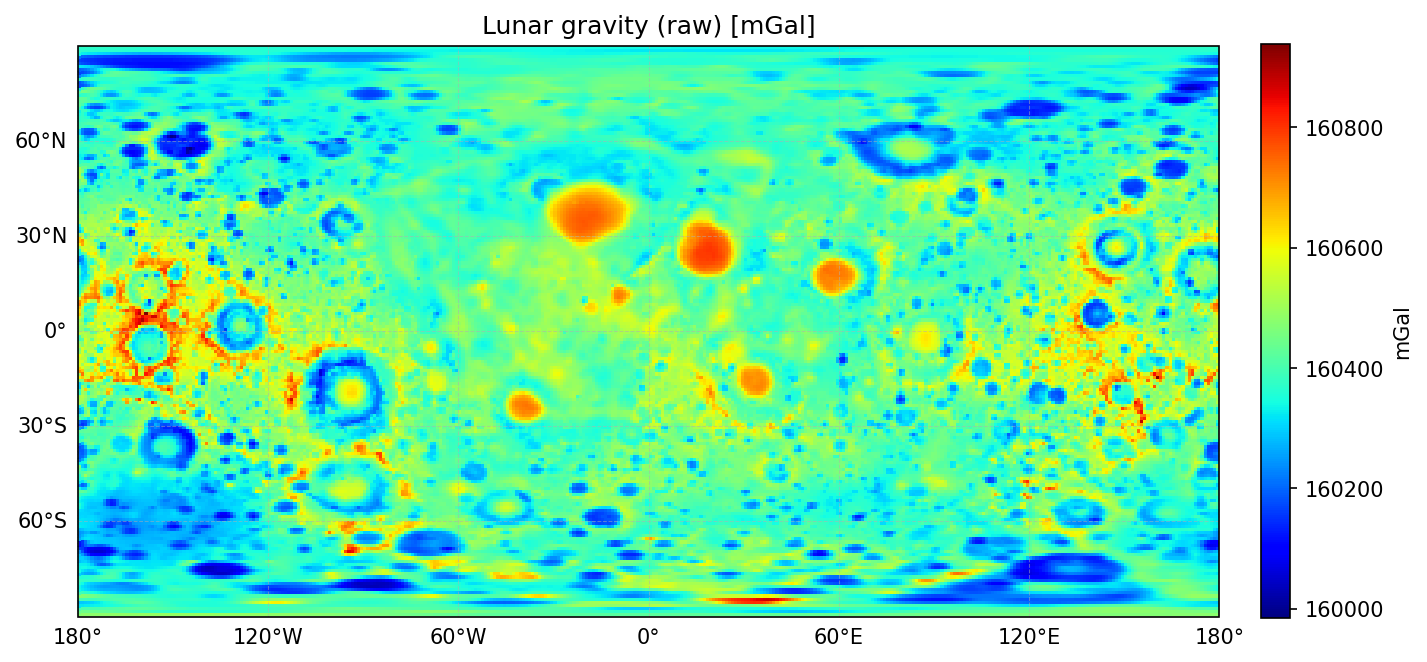

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Lunar gravity (raw) [mGal]'}>)

In [9]:
data=-pot_xr_sub.radial.data*1e5
freeair_xr=xr.DataArray(data,dims=('lat','lon'),coords={'lat': lat,'lon': lon})

simple_map_plot(
    freeair_xr,
    title="Lunar gravity (raw) [mGal]",
    cbar_label="mGal",
    cmap="jet",
)

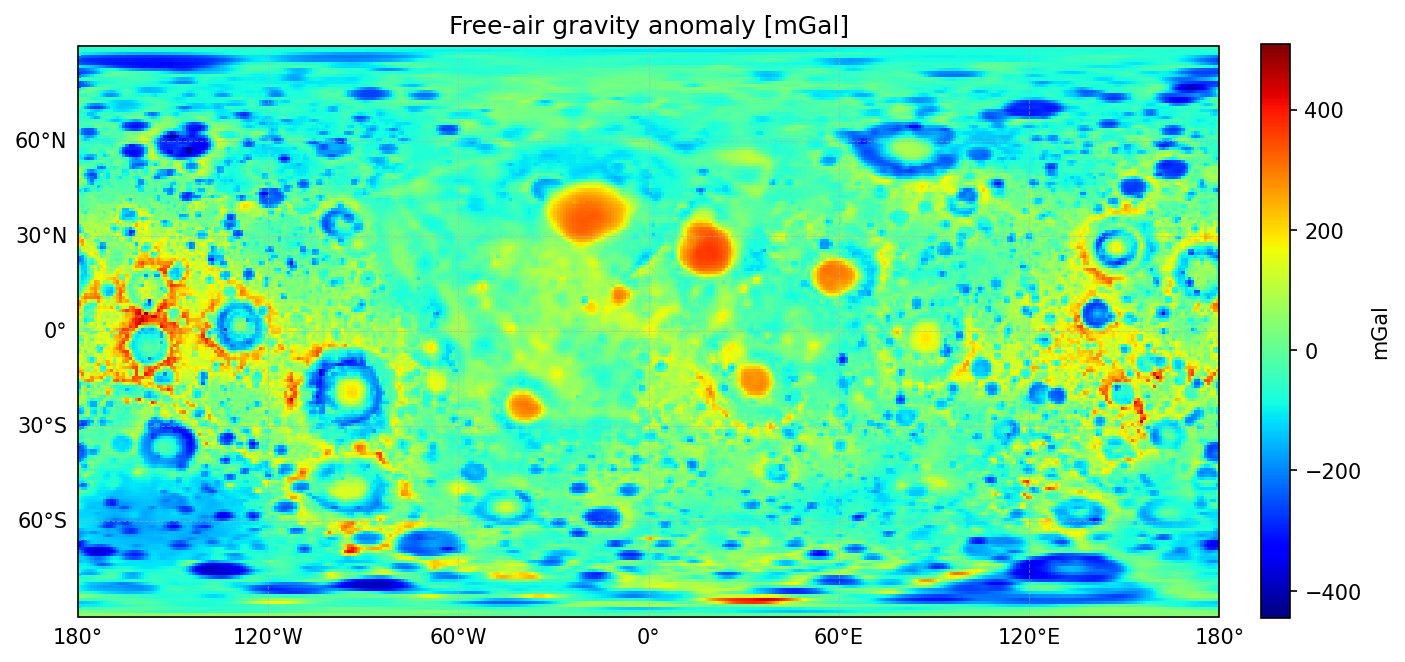

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Free-air gravity anomaly [mGal]'}>)

In [10]:
data=-pot_xr_sub.radial.data*1e5-gamma
freeair_xr=xr.DataArray(data,dims=('lat','lon'),coords={'lat': lat,'lon': lon})

simple_map_plot(
    freeair_xr,
    title="Free-air gravity anomaly [mGal]",
    cbar_label="mGal",
    cmap="jet",
)

In [11]:
surface=topo_xr_sub.data

density_array=density_xr_sub.data.copy()
density_array[(topo_xr_sub.data-bl.Moon2015.mean_radius)<=0]*=-1
density_array*=(1-porosity)

reference=bl.Moon2015.mean_radius*np.ones_like(LAT)
coordinates=(LON,LAT,reference+height)
topo_layer=hm.tesseroid_layer((lon,lat),surface=surface,reference=reference,properties={"density":density_array})
topo_g=topo_layer.tesseroid_layer.gravity(coordinates, field="g_z",progressbar=False)

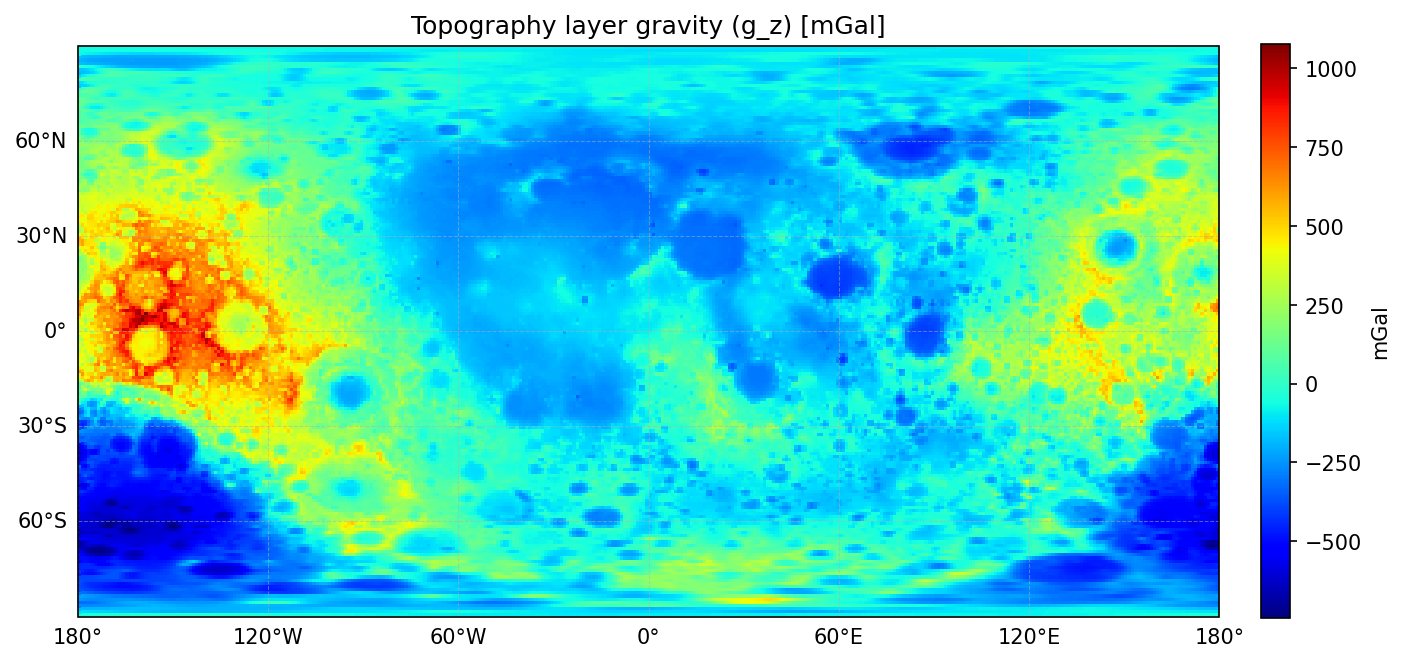

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Topography layer gravity (g_z) [mGal]'}>)

In [12]:
topo_g_xr=freeair_xr.copy()
topo_g_xr.data=topo_g

simple_map_plot(
    topo_g_xr,
    title="Topography layer gravity (g_z) [mGal]",
    cbar_label="mGal",
    cmap="jet",
)

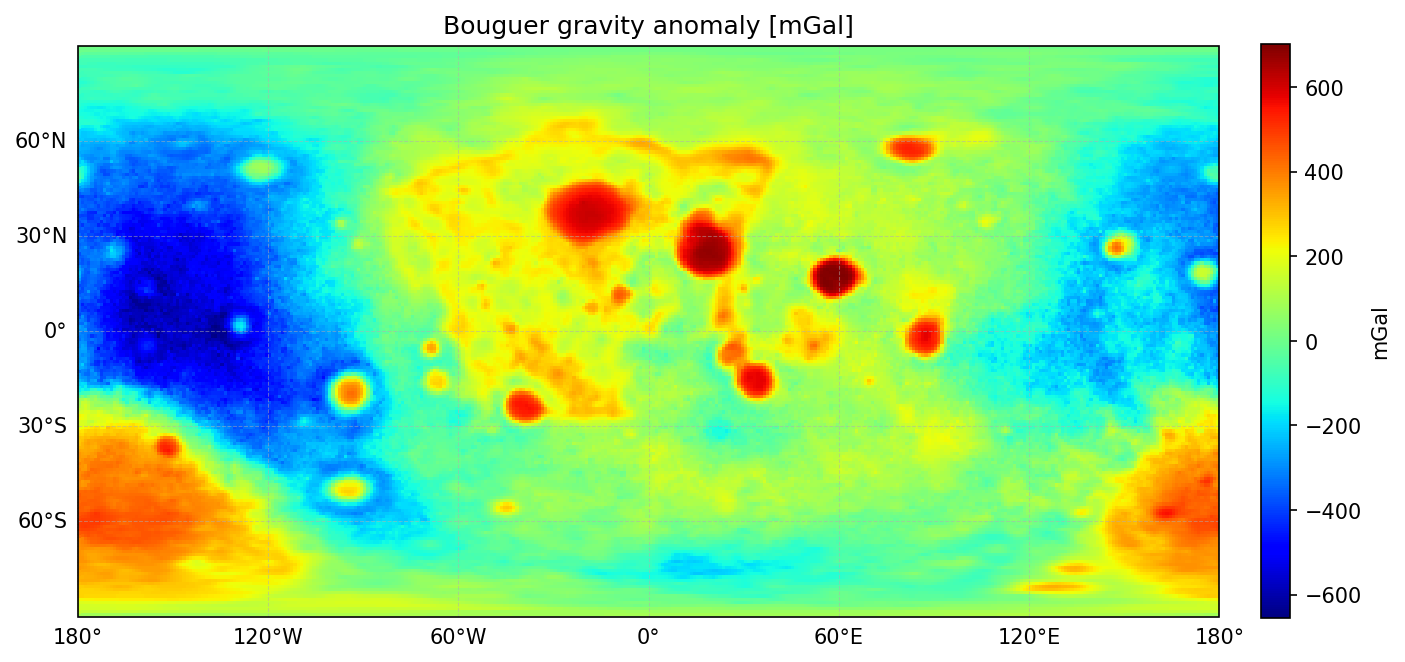

(<Figure size 1500x720 with 2 Axes>,
 <GeoAxes: title={'center': 'Bouguer gravity anomaly [mGal]'}>)

In [13]:
boueguer_xr=freeair_xr.copy()
boueguer_xr.data-=topo_g

simple_map_plot(
    boueguer_xr,
    title="Bouguer gravity anomaly [mGal]",
    cbar_label="mGal",
    cmap="jet",
)

In [14]:
df=(
    boueguer_xr
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='deltaN')
    .reset_index(drop=True)
)
topo_xr_sub.data=topo_xr_sub.data-bl.Moon2015.mean_radius
df_topo=(
    topo_xr_sub
    .stack(points=('lat','lon'))
    .reset_index('points')
    .to_dataframe(name='topo')
    .reset_index(drop=True)
)
df=df.merge(df_topo,on=['lon', 'lat'],how='left')
df

,lat,lon,deltaN,topo
0,-89.5,0.50000,87.023562,-569.232321
1,-89.5,1.50000,87.035470,-543.178360
2,-89.5,2.50000,87.043465,-516.746566
3,-89.5,3.50000,87.047672,-490.063888
4,-89.5,4.50000,87.048222,-463.249504
...,...,...,...,...
64795,89.5,355.49999,8.389035,-769.563546
64796,89.5,356.49999,8.461708,-787.592314
64797,89.5,357.49999,8.535528,-805.228264
64798,89.5,358.49999,8.610481,-822.395518


In [15]:
df.to_csv(
    result_filename,
    index=False,        # 不输出行号
    float_format='%.6f' # 控制浮点精度，重力数据一般够用
)